# 2. Modelo XGBoost

Segundo modelo de clasificación binaria para predecir Heart Disease usando XGBoost (gradient boosting).

**Estrategia:**
1. Modelo base con parámetros por defecto
2. Búsqueda de hiperparámetros con RandomizedSearchCV + StratifiedKFold
3. Modelo final con los mejores hiperparámetros
4. Análisis de importancia de features

**Evaluación:** ROC-AUC mediante cross-validation (5-fold)  
**Baseline (LR):** ROC-AUC ~ 0.9505

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import uniform, randint
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

## 2. Carga de datos

In [2]:
df = pd.read_csv("../../data/train.csv")

# Target binario
df["target"] = (df["Heart Disease"] == "Presence").astype(int)

# Features
continuous_features = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]
categorical_features = ["Sex", "Chest pain type", "FBS over 120", "EKG results",
                        "Exercise angina", "Slope of ST", "Number of vessels fluro", "Thallium"]
all_features = continuous_features + categorical_features

y = df["target"]
X = df[all_features]

print(f"Shape: {X.shape}")
print(f"Target balance: {y.mean():.2%} Presence")

Shape: (630000, 13)
Target balance: 44.83% Presence


## 3. Modelo Base — XGBoost con parámetros por defecto

In [3]:
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_scores = []
base_fpr_list, base_tpr_list = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb_base.fit(X_train, y_train, verbose=False)
    y_prob = xgb_base.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, y_prob)
    base_scores.append(auc)

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    base_fpr_list.append(fpr)
    base_tpr_list.append(tpr)

    print(f"  Fold {fold}: ROC-AUC = {auc:.4f}")

print(f"\nModelo Base - ROC-AUC: {np.mean(base_scores):.4f} (+/- {np.std(base_scores):.4f})")

  Fold 1: ROC-AUC = 0.9549
  Fold 2: ROC-AUC = 0.9540
  Fold 3: ROC-AUC = 0.9548
  Fold 4: ROC-AUC = 0.9543
  Fold 5: ROC-AUC = 0.9552

Modelo Base - ROC-AUC: 0.9547 (+/- 0.0004)


## 4. Búsqueda de Hiperparámetros — RandomizedSearchCV

Parámetros a optimizar:
- `max_depth`: profundidad máxima del árbol
- `learning_rate`: tasa de aprendizaje (eta)
- `n_estimators`: número de árboles
- `min_child_weight`: peso mínimo en nodos hoja
- `subsample`: fracción de muestras por árbol
- `colsample_bytree`: fracción de features por árbol
- `gamma`: regularización por complejidad del árbol

**Estrategia:** RandomizedSearchCV con 50 iteraciones y 5-fold StratifiedKFold.

In [4]:
param_distributions = {
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.29),
    "n_estimators": randint(100, 1001),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma": uniform(0, 0.5),
}

xgb_search = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
)

skf_search = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_search,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="roc_auc",
    cv=skf_search,
    random_state=42,
    verbose=1,
    n_jobs=1,
    return_train_score=False,
)

random_search.fit(X, y)

print(f"\nMejor ROC-AUC (CV): {random_search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejor ROC-AUC (CV): nan

Mejores hiperparámetros:
  colsample_bytree: 0.749816047538945
  gamma: 0.4753571532049581
  learning_rate: 0.22227824312530747
  max_depth: 7
  min_child_weight: 5
  n_estimators: 714
  subsample: 0.7783331011414365


In [5]:
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results = cv_results.sort_values("rank_test_score")

top10 = cv_results[["rank_test_score", "mean_test_score", "std_test_score",
                     "param_max_depth", "param_learning_rate", "param_n_estimators",
                     "param_min_child_weight", "param_subsample",
                     "param_colsample_bytree", "param_gamma"]].head(10)

print("Top 10 configuraciones:")
print(top10.to_string(index=False))

Top 10 configuraciones:
 rank_test_score  mean_test_score  std_test_score  param_max_depth  param_learning_rate  param_n_estimators  param_min_child_weight  param_subsample  param_colsample_bytree  param_gamma
               1              NaN             NaN                7             0.222278                 714                       5         0.778333                0.749816     0.475357
               1              NaN             NaN                5             0.106775                 408                       6         0.987964                0.639990     0.229624
               1              NaN             NaN                7             0.062729                 559                       1         0.844661                0.932977     0.106170
               1              NaN             NaN                9             0.162185                 975                       3         0.805694                0.602827     0.011531
               1              NaN             

## 5. Evaluación del Mejor Modelo — Cross-Validation Detallado

In [6]:
best_params = random_search.best_params_

xgb_best = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    **best_params
)

skf_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_scores = []
best_fpr_list, best_tpr_list = [], []

for fold, (train_idx, val_idx) in enumerate(skf_eval.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb_best.fit(X_train, y_train, verbose=False)
    y_prob = xgb_best.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, y_prob)
    best_scores.append(auc)

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    best_fpr_list.append(fpr)
    best_tpr_list.append(tpr)

    print(f"  Fold {fold}: ROC-AUC = {auc:.4f}")

print(f"\nMejor Modelo - ROC-AUC: {np.mean(best_scores):.4f} (+/- {np.std(best_scores):.4f})")

  Fold 1: ROC-AUC = 0.9522
  Fold 2: ROC-AUC = 0.9512
  Fold 3: ROC-AUC = 0.9521
  Fold 4: ROC-AUC = 0.9516
  Fold 5: ROC-AUC = 0.9524

Mejor Modelo - ROC-AUC: 0.9519 (+/- 0.0004)


## 6. Curvas ROC

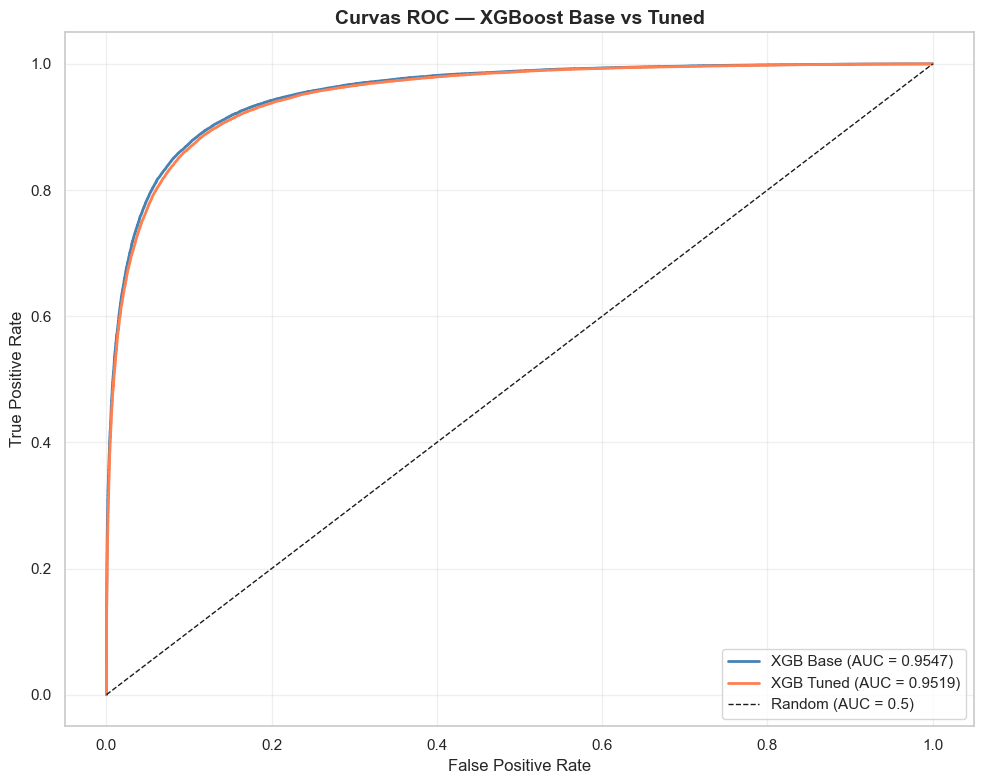

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(base_fpr_list[-1], base_tpr_list[-1], color="steelblue", linewidth=2,
        label=f"XGB Base (AUC = {np.mean(base_scores):.4f})")

ax.plot(best_fpr_list[-1], best_tpr_list[-1], color="coral", linewidth=2,
        label=f"XGB Tuned (AUC = {np.mean(best_scores):.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Curvas ROC \u2014 XGBoost Base vs Tuned", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Importancia de Features

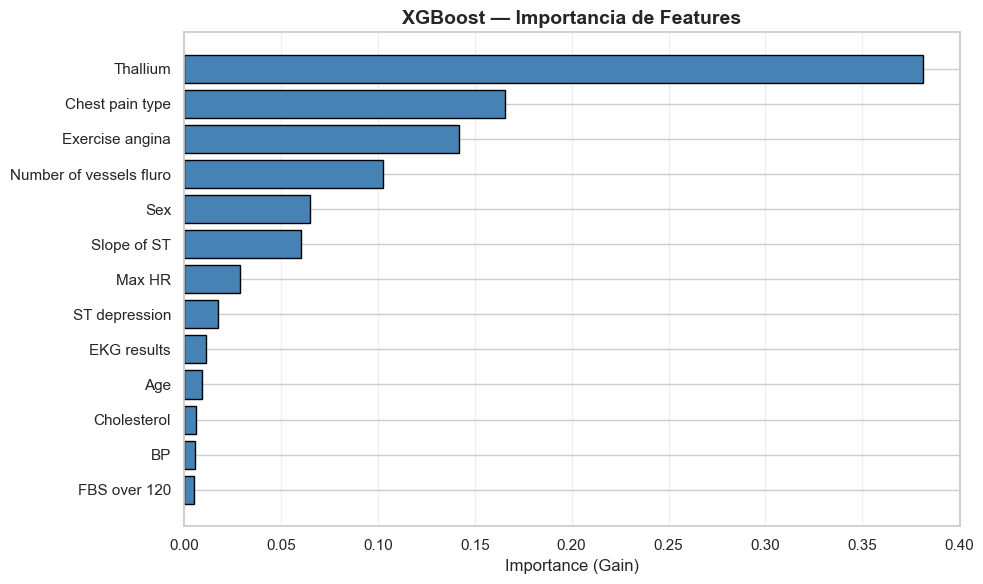


Importancia ordenada:
  Thallium                       0.3813
  Chest pain type                0.1654
  Exercise angina                0.1420
  Number of vessels fluro        0.1025
  Sex                            0.0649
  Slope of ST                    0.0605
  Max HR                         0.0288
  ST depression                  0.0175
  EKG results                    0.0115
  Age                            0.0090
  Cholesterol                    0.0060
  BP                             0.0054
  FBS over 120                   0.0051


In [8]:
xgb_final = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    **best_params
)
xgb_final.fit(X, y, verbose=False)

importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": xgb_final.feature_importances_,
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance["Feature"], importance["Importance"], color="steelblue", edgecolor="black")
ax.set_xlabel("Importance (Gain)", fontsize=12)
ax.set_title("XGBoost \u2014 Importancia de Features", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print("\nImportancia ordenada:")
for _, row in importance.sort_values("Importance", ascending=False).iterrows():
    print(f"  {row['Feature']:30s} {row['Importance']:.4f}")

## 8. Guardar modelo

In [9]:
model_dir = "../../models"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "2_xgboost_best.pkl")
joblib.dump({
    "model": xgb_final,
    "best_params": best_params,
    "features": all_features,
    "cv_score": np.mean(best_scores),
    "cv_std": np.std(best_scores),
}, model_path)

print(f"Modelo guardado en: {model_path}")
print(f"  ROC-AUC (CV): {np.mean(best_scores):.4f} +/- {np.std(best_scores):.4f}")
print(f"  Hiperparámetros: {best_params}")
print(f"  Features: {all_features}")

Modelo guardado en: ../../models\2_xgboost_best.pkl
  ROC-AUC (CV): 0.9519 +/- 0.0004
  Hiperparámetros: {'colsample_bytree': np.float64(0.749816047538945), 'gamma': np.float64(0.4753571532049581), 'learning_rate': np.float64(0.22227824312530747), 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 714, 'subsample': np.float64(0.7783331011414365)}
  Features: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression', 'Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


## 9. Comparación de Modelos

In [10]:
comparison = pd.DataFrame({
    "Modelo": ["LR (todas, 13 vars)", "LR (significativas, 9 vars)", "XGB Base (13 vars)", "XGB Tuned (13 vars)"],
    "N Variables": [13, 9, 13, 13],
    "ROC-AUC Mean": [0.9505, 0.9485, np.mean(base_scores), np.mean(best_scores)],
    "ROC-AUC Std": [0.0003, 0.0005, np.std(base_scores), np.std(best_scores)],
})
comparison["ROC-AUC"] = comparison.apply(
    lambda r: f"{r['ROC-AUC Mean']:.4f} +/- {r['ROC-AUC Std']:.4f}", axis=1
)

print("=" * 80)
print("COMPARACION DE MODELOS")
print("=" * 80)
print(comparison[["Modelo", "N Variables", "ROC-AUC"]].to_string(index=False))
print("=" * 80)

COMPARACION DE MODELOS
                     Modelo  N Variables           ROC-AUC
        LR (todas, 13 vars)           13 0.9505 +/- 0.0003
LR (significativas, 9 vars)            9 0.9485 +/- 0.0005
         XGB Base (13 vars)           13 0.9547 +/- 0.0004
        XGB Tuned (13 vars)           13 0.9519 +/- 0.0004


## 10. Resumen

**Modelo seleccionado:** XGBoost con hiperparámetros optimizados (RandomizedSearchCV, 50 iteraciones, 5-fold).

**Próximo paso:** Generar submission con el modelo optimizado en `notebooks/submissions/2_XGB_submission.ipynb`.